# Gaussian processes from scratch — a fill-in tutorial

Goal: build, with your own hands, every piece of the GP machinery that
`clean_experiments/fire_sims/06_gp.ipynb` uses on the FIRE LOS problem — in 1D
first, then derivative observations (the trick that powers the whole project),
then a 2D toy of the real problem.

**Companion:** `GP_WALKTHROUGH.md` in this folder derives everything here on
paper and maps it to the real notebook. This tutorial references its exercises;
do the two in either order.

**How this works.** Cells with a `FILL-IN` banner raise `NotImplementedError`
until you write the missing lines. Each is followed by a ✅ CHECK cell that
tests your code against closed forms or finite differences — run it and it will
tell you if you are right. `solutions.py` sits next to this notebook; the rule
is that a check must beat you **twice** before you open it.

Roadmap:

1. the kernel, and sampling from the prior
2. conditioning — the posterior
3. Cholesky + the log evidence
4. fitting hyperparameters by evidence
5. **derivative observations** — recovering $f$ from measurements of $f'$
6. capstone: a 2D "LOS accelerations" toy of the real problem

Run it in the repo environment (`uv run jupyter lab`, or select the repo venv
as the kernel).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update('jax_enable_x64', True)   # GPs are dense linear algebra -> float64
import jax.numpy as jnp

rng = np.random.default_rng(0)

## Part 1 — the kernel, and what a GP prior is

A Gaussian process is a probability distribution over *functions*: for any
finite set of points $x_1,\dots,x_n$, the values $f(x_1),\dots,f(x_n)$ are
jointly Gaussian with mean 0 (here) and covariance matrix
$K_{ij} = k(x_i, x_j)$. The **kernel** $k$ *is* the prior: it says how much
function values covary as a function of where they are.

The workhorse (and the one `06_gp.ipynb` uses, as `kfun`) is the
squared-exponential kernel

$$k(x, x') = A^2 \exp\!\left(-\frac{(x - x')^2}{2\ell^2}\right),$$

with $A$ the typical size of the function and $\ell$ the distance over which it
decorrelates — the "wiggle scale". Nearby points: covariance $\approx A^2$,
strongly correlated. Distant points: independent.

**FILL-IN 1** below: implement it. One practical instruction: use `jnp.exp`,
not `np.exp` — in Part 5 we will *differentiate your kernel with JAX*, exactly
like the real notebook does, and that requires it to be written in `jnp`.

In [9]:
import jax.numpy as jnp

x1 = jnp.array([1, 1])
x2 = jnp.array([2, 3])

result = x1 - x2
print(result) # Output: [-1 -1]
print(jnp.dot(result,result))


[-1 -2]
5


In [12]:
# =========================== FILL-IN 1 ===========================
def se_kernel(x1, x2, A, ell):
    """Squared-exponential kernel  k(x1, x2) = A^2 exp(-(x1-x2)^2 / (2 ell^2)).

    Write it as a single jnp expression (no ifs/loops): then it works on
    scalars AND broadcasts over arrays, and jax can differentiate it.
    """
    exponent = - (x1 - x2) ** 2 / ( 2 * ell**2)
    return A ** 2 * jnp.exp(exponent)

def kernel_matrix(xs1, xs2, A, ell):
    """(n,) and (m,) point arrays -> (n, m) matrix  K[i, j] = k(xs1[i], xs2[j]).

    Hint: broadcasting — feed se_kernel  xs1[:, None]  and  xs2[None, :].
    """
    K = se_kernel(xs1[:,None], xs2[None,:], A, ell)
    return K

In [13]:
# ✅ CHECK 1
K = kernel_matrix(np.linspace(-3, 3, 40), np.linspace(-3, 3, 40), 2.0, 1.0)
assert K.shape == (40, 40), 'kernel_matrix must return an (n, m) matrix'
assert np.isclose(float(se_kernel(0.0, 0.0, 2.0, 1.0)), 4.0), 'k(x, x) must equal A^2'
assert np.isclose(float(se_kernel(0.0, 1.0, 2.0, 1.0)), 4.0 * np.exp(-0.5)), \
    'k one length-scale apart must be A^2 e^{-1/2}'
assert np.allclose(K, K.T), 'the kernel matrix must be symmetric'
assert np.linalg.eigvalsh(np.asarray(K)).min() > -1e-9, \
    'the kernel matrix must be positive semi-definite'
print('CHECK 1 passed: valid SE kernel.')

CHECK 1 passed: valid SE kernel.


**Sampling the prior** (provided — read it). If $z \sim N(0, I)$ and
$K = LL^\top$ is a Cholesky factorization, then $f = Lz$ has
$\operatorname{Cov}(f) = LL^\top = K$: that is the whole recipe for drawing
functions from the prior. The tiny "jitter" added to the diagonal is standard
practice — $K$ is positive semi-definite in exact arithmetic, and floating
point needs a nudge to keep the factorization from failing.

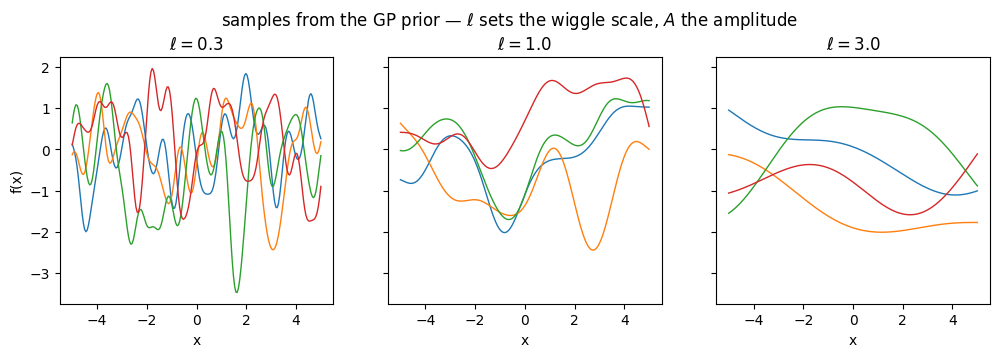

In [14]:
xs = np.linspace(-5, 5, 200)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, ell in zip(axes, (0.3, 1.0, 3.0)):
    K = np.asarray(kernel_matrix(xs, xs, 1.0, ell))
    L = np.linalg.cholesky(K + 1e-10 * np.eye(len(xs)))       # jitter
    ax.plot(xs, L @ rng.standard_normal((len(xs), 4)), lw=1)
    ax.set_title(f'$\\ell = {ell}$'); ax.set_xlabel('x')
axes[0].set_ylabel('f(x)')
fig.suptitle('samples from the GP prior — $\\ell$ sets the wiggle scale, $A$ the amplitude', y=1.03)
plt.show()

## Part 2 — conditioning: the posterior

Observe $y_i = f(x_i) + \varepsilon_i$ with $\varepsilon_i \sim N(0,\sigma^2)$.
Because data and any test values $f(X_*)$ are *jointly Gaussian*, conditioning
is pure linear algebra (derivation: walkthrough **Exercise 1** — do it on paper
first, it is two lines):

$$C = K(X, X) + \sigma^2 I,\qquad
\mathbb{E}[f(X_*) \mid y] = K(X_*, X)\, C^{-1} y,$$
$$\operatorname{Cov}[f(X_*) \mid y] = K(X_*, X_*) - K(X_*, X)\, C^{-1} K(X, X_*).$$

Two things to notice before implementing: the posterior covariance does **not**
contain $y$ (the error bars of a linear-Gaussian experiment are fixed by its
design — the fact behind fig 9 of the real notebook), and numerically you
should never form $C^{-1}$ — solve linear systems instead.

In [ ]:
# =========================== FILL-IN 2 ===========================
def gp_posterior(X, y, Xstar, A, ell, sigma):
    """GP regression posterior:  X (n,), y (n,), Xstar (m,) -> mean (m,), cov (m, m).

    Use np.linalg.solve(C, ...) — never an explicit inverse.
    """
    Kxx = np.asarray(kernel_matrix(X, X, A, ell))
    Ksx = np.asarray(kernel_matrix(Xstar, X, A, ell))
    Kss = np.asarray(kernel_matrix(Xstar, Xstar, A, ell))
    # YOUR CODE HERE (~3 lines): C, then mean and cov from the formulas above

    C = Kxx + sigma**2 * np.eye(len(X))
    mean = Ksx @ np.linalg.solve(C, y)
    cov = Kss - Ksx @ np.linalg.solve(C, Ksx.T)
    return mean, cov

In [ ]:
# ✅ CHECK 2
Xd = np.array([-2.0, -0.5, 1.0, 2.5]); yd = np.array([0.5, -1.0, 0.3, 1.2])
m, S = gp_posterior(Xd, yd, Xd, A=1.5, ell=1.0, sigma=1e-6)
assert np.allclose(m, yd, atol=1e-3), 'with ~zero noise the mean must interpolate the data'
assert np.all(np.diag(S) < 1e-5), '...and the variance at the data points must vanish'
m2, S2 = gp_posterior(Xd, yd, np.array([40.0]), A=1.5, ell=1.0, sigma=1e-6)
assert abs(S2[0, 0] - 1.5**2) < 1e-8 and abs(m2[0]) < 1e-8, \
    'far from all data the prior must be recovered: mean 0, variance A^2'
print('CHECK 2 passed: conditioning works.')

In [ ]:
# the classic picture (provided): mean, band, posterior samples
f_true = lambda x: np.sin(2 * x) + 0.5 * x
Xd = np.sort(rng.uniform(-4, 4, 8)); yd = f_true(Xd) + 0.15 * rng.standard_normal(8)
xs = np.linspace(-6, 6, 300)
m, S = gp_posterior(Xd, yd, xs, A=2.0, ell=1.0, sigma=0.15)
sd = np.sqrt(np.clip(np.diag(S), 0, None))
plt.figure(figsize=(9, 4))
plt.fill_between(xs, m - 2 * sd, m + 2 * sd, alpha=0.25, label='$\\pm 2\\sigma$')
L = np.linalg.cholesky(S + 1e-9 * np.eye(len(xs)))
plt.plot(xs, m[:, None] + L @ rng.standard_normal((len(xs), 3)), lw=0.7, color='0.5')
plt.plot(xs, f_true(xs), 'k--', lw=1, label='truth')
plt.plot(xs, m, lw=2, label='posterior mean')
plt.plot(Xd, yd, 'ko', ms=5, label='data')
plt.legend()
plt.title('the posterior: pinned at the data, reverting to the prior away from it')
plt.show()

## Part 3 — doing it properly: Cholesky and the log evidence

Since $y \sim N(0, C)$ under the prior, the **marginal likelihood (evidence)**
of the data is an ordinary Gaussian density:

$$-\log p(y) \;=\;
\underbrace{\tfrac12\, y^\top C^{-1} y}_{\text{data fit}}
\;+\; \underbrace{\tfrac12 \log\det C}_{\text{complexity}}
\;+\; \tfrac n2 \log 2\pi .$$

The professional implementation factors $C = LL^\top$ **once** (Cholesky:
stable, and half the cost of LU) and reuses $L$ for everything:
$C^{-1}y$ by two triangular solves (`cho_solve`), and
$\log\det C = 2\sum_i \log L_{ii}$ for free off the diagonal.

This fill-in mirrors, line for line, `neg_log_evidence` in `06_gp.ipynb`
(cell 3) — including heteroscedastic noise: a *vector* `nvar` of per-datum
noise variances (the catalog gives every pulsar its own $\sigma_j$), added on
the diagonal.

In [ ]:
# =========================== FILL-IN 3 ===========================
import jax.scipy.linalg as jsl

def neg_log_evidence(y, K, nvar):
    """-log p(y)  for  y ~ N(0, C),  C = K + diag(nvar).   (all jnp arrays)

    Steps:
        C     = K + diag(nvar)
        L     = cholesky of C                    (jnp.linalg.cholesky)
        alpha = C^{-1} y                         (jsl.cho_solve((L, True), y))
        return  0.5 * y.alpha  +  sum(log diag L)  +  0.5 * n * log(2 pi)

    Question to answer on paper: why is  sum(log diag L) = 0.5 log det C ?
    """
    # YOUR CODE HERE (~4 lines)
    raise NotImplementedError

In [ ]:
# ✅ CHECK 3 — against scipy's multivariate normal
from scipy.stats import multivariate_normal
yt = rng.standard_normal(15)
Xt = np.linspace(0, 5, 15)
Kt = np.asarray(kernel_matrix(Xt, Xt, 1.3, 0.8))
nv = rng.uniform(0.05, 0.3, 15)
mine = float(neg_log_evidence(jnp.asarray(yt), jnp.asarray(Kt), jnp.asarray(nv)))
ref = -multivariate_normal(mean=np.zeros(15), cov=Kt + np.diag(nv)).logpdf(yt)
assert abs(mine - ref) < 1e-8, f'got {mine}, scipy says {ref}'
print(f'CHECK 3 passed: -log evidence = {mine:.4f} (scipy agrees).')

## Part 4 — fitting $\ell$ and $A$ by evidence (type-II maximum likelihood)

The evidence's two active terms fight each other: a flexible prior (large $A$,
small $\ell$) can fit anything — the data-fit term goes down — but it spreads
its probability over a huge volume of functions, so $\log\det C$ goes up.
Minimizing the *sum* is an automatic Occam's razor: no validation set, no
cross-validation. `06_gp.ipynb` does exactly this with a 13×17 grid
(`ELLS` × `LOGA_GRID`) and one Cholesky per grid point.

Test protocol here: **draw** data from a GP with known $(\ell, A)$, then check
the evidence finds them back from a single realization.

In [ ]:
# =========================== FILL-IN 4 ===========================
def fit_hypers(X, y, nvar, ells, As):
    """Exhaustive grid search over (ell, A): return (best_ell, best_A, best_nle).

    For each pair: build the kernel matrix, score it with neg_log_evidence,
    keep the argmin. Brute force is fine here (06_gp.ipynb factors out
    A^2 * K_unit to reuse the expensive part — same idea, optimized).
    """
    # YOUR CODE HERE (~8 lines, two loops)
    raise NotImplementedError

In [ ]:
# ✅ CHECK 4 — recover known hyperparameters from one draw
ELL_TRUE, A_TRUE, SIG = 1.2, 2.0, 0.1
Xg = np.linspace(-6, 6, 60)
Kg = np.asarray(kernel_matrix(Xg, Xg, A_TRUE, ELL_TRUE))
yg = (np.linalg.cholesky(Kg + 1e-10 * np.eye(60)) @ rng.standard_normal(60)
      + SIG * rng.standard_normal(60))
ells, As = np.geomspace(0.2, 6.0, 13), np.geomspace(0.3, 8.0, 13)
nvarg = np.full(60, SIG**2)
ell_hat, A_hat, _ = fit_hypers(Xg, yg, nvarg, ells, As)
print(f'truth: ell = {ELL_TRUE}, A = {A_TRUE}   '
      f'evidence picks: ell = {ell_hat:.2f}, A = {A_hat:.2f}')

NLE = np.array([[float(neg_log_evidence(jnp.asarray(yg),
                                        jnp.asarray(kernel_matrix(Xg, Xg, A, ell)),
                                        jnp.asarray(nvarg)))
                 for A in As] for ell in ells])
plt.figure(figsize=(6, 4.5))
plt.pcolormesh(As, ells, NLE - NLE.min(), cmap='viridis_r', shading='auto', vmax=30)
plt.colorbar(label='-log evidence (above minimum)')
plt.plot(A_TRUE, ELL_TRUE, 'w*', ms=16, mec='k', label='truth')
plt.plot(A_hat, ell_hat, 'o', color='orange', mec='k', label='evidence argmin')
plt.xscale('log'); plt.yscale('log'); plt.xlabel('A'); plt.ylabel('$\\ell$')
plt.legend(); plt.title('the evidence surface — Occam picks the right prior')
plt.show()
assert 0.5 * ELL_TRUE < ell_hat < 2.0 * ELL_TRUE, \
    'the recovered ell should land within a factor 2 of the truth'
print('CHECK 4 passed: hyperparameters recovered.')

## Part 5 — the derivative trick

Here is the fact the whole project stands on: **derivatives of a GP are again a
GP.** A derivative is a limit of finite differences, finite differences are
linear combinations of function values, and covariance is bilinear — so the
derivative operators land on the *kernel*, one per argument:

$$\operatorname{Cov}\big(f'(t_1), f'(t_2)\big) = \frac{\partial^2 k}{\partial t_1 \partial t_2},
\qquad
\operatorname{Cov}\big(f(t), f'(t_2)\big) = \frac{\partial k}{\partial t_2}.$$

Why this matters: in the real problem we **never observe $\Phi$** — only
$-\hat u\cdot\nabla\Phi$ (LOS accelerations). The 1D analog: observe only
$s_j = f'(t_j) + \varepsilon_j$, and reconstruct $f$ itself, *with error bars*.
No numerical integration of the data — just kernel derivatives and the same
conditioning formula as Part 2.

And the implementation trick from `06_gp.ipynb` cell 3: don't derive the
kernel derivatives by hand for the code (you derive them by hand on paper —
walkthrough §4 — as the *unit test*); let `jax.grad` do it. E.g.
`jax.grad(se_kernel, argnums=1)` is $\partial k/\partial t_2$ as a callable.

In [ ]:
# =========================== FILL-IN 5 ===========================
def k_dd(t1, t2, A, ell):
    """Cov(f'(t1), f'(t2)) = d^2 k / dt1 dt2 — one jax.grad per argument.

    No hand-derived formulas allowed: build it from se_kernel with
    jax.grad (argnums=...). The check cell holds you to finite differences.
    """
    # YOUR CODE HERE (1-2 lines)
    raise NotImplementedError


def k_fd(t, t2, A, ell):
    """Cov(f(t), f'(t2)) = d k / dt2   (derivative on the SECOND argument)."""
    # YOUR CODE HERE (one line)
    raise NotImplementedError

In [ ]:
# ✅ CHECK 5 — autodiff vs finite differences, plus one closed form
h, t1, t2, A_, ell_ = 1e-4, 0.7, -0.4, 1.3, 0.9
fd1 = (float(se_kernel(t1, t2 + h, A_, ell_))
       - float(se_kernel(t1, t2 - h, A_, ell_))) / (2 * h)
assert abs(float(k_fd(t1, t2, A_, ell_)) - fd1) < 1e-6, \
    'k_fd disagrees with finite differences'
fd2 = (float(k_fd(t1 + h, t2, A_, ell_))
       - float(k_fd(t1 - h, t2, A_, ell_))) / (2 * h)
assert abs(float(k_dd(t1, t2, A_, ell_)) - fd2) < 1e-5, \
    'k_dd disagrees with finite differences'
assert abs(float(k_dd(0.0, 0.0, A_, ell_)) - A_**2 / ell_**2) < 1e-9, \
    "prior Var(f') must be A^2/ell^2 — walkthrough Ex. 3 at r = 0"
print('CHECK 5 passed: kernel derivatives correct.')

In [ ]:
# recovering f from derivative-only data (provided) — and the GAUGE
f_tr = lambda t: np.sin(1.5 * t) + 0.3 * t**2         # what we want
fp_tr = lambda t: 1.5 * np.cos(1.5 * t) + 0.6 * t     # what we measure
SIG = 0.1
Td = np.sort(rng.uniform(-3, 3, 12))
s_obs = fp_tr(Td) + SIG * rng.standard_normal(12)

A_, ell_ = 3.0, 1.0
Kdd = np.array([[float(k_dd(a, b, A_, ell_)) for b in Td] for a in Td])
C = Kdd + SIG**2 * np.eye(len(Td))
alpha = np.linalg.solve(C, s_obs)                      # C^{-1} s

ts = np.linspace(-4, 4, 200)
Kfd = np.array([[float(k_fd(t, b, A_, ell_)) for b in Td] for t in ts])
mean_f = Kfd @ alpha
var_f = A_**2 - np.einsum('ij,ij->i', Kfd, np.linalg.solve(C, Kfd.T).T)

# the gauged DIFFERENCE functional f(t) - f(0): also linear, so same formula,
# with cross-covariance = difference of the two k_fd rows (cf. phi_gauged)
K0 = np.array([float(k_fd(0.0, b, A_, ell_)) for b in Td])
cdiff = Kfd - K0[None, :]
k_t0 = np.array([float(se_kernel(t, 0.0, A_, ell_)) for t in ts])
prior_diff = 2 * A_**2 - 2 * k_t0
var_diff = prior_diff - np.einsum('ij,ij->i', cdiff, np.linalg.solve(C, cdiff.T).T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
i0 = np.argmin(np.abs(ts))
axes[0].plot(ts, f_tr(ts) - (f_tr(0.0) - mean_f[i0]), 'k--', label='truth (constant aligned)')
axes[0].plot(ts, mean_f, lw=2, label='posterior mean of $f$')
axes[0].plot(Td, np.zeros_like(Td), 'k|', ms=14, label="$f'$ measurement locations")
axes[0].legend(); axes[0].set_xlabel('t')
axes[0].set_title('f recovered from DERIVATIVE data only —\nup to a constant no derivative can fix')
axes[1].plot(ts, np.sqrt(np.clip(var_f, 0, None)), label='$\\sigma[f(t)]$ pointwise')
axes[1].plot(ts, np.sqrt(np.clip(var_diff, 0, None)), label='$\\sigma[f(t) - f(0)]$ (gauged)')
axes[1].axhline(A_, color='0.6', ls=':', label='prior $\\sigma = A$')
axes[1].legend(); axes[1].set_xlabel('t')
axes[1].set_title('the gauge: the pointwise band never beats the unknown\nconstant; the DIFFERENCE is what the data measure')
plt.show()

What you just saw is, exactly, the real notebook's situation:

- the posterior mean of $f$ tracks the truth **up to an additive constant** —
  gradient data cannot know it, so the constant is prior-set. For $\Phi$ from
  LOS accelerations it is the same story;
- the *pointwise* $\sigma[f(t)]$ (left curve of the right panel) never drops
  much below the prior $A$ — honest, but not what the experiment measures;
- the **difference functional** $f(t) - f(0)$ is itself linear in $f$, so the
  same conditioning formula applies, the unknown constant cancels, and its
  $\sigma$ genuinely shrinks. This is precisely `phi_gauged` in `06_gp.ipynb`
  (cell 3) and the ±2σ band of its fig 2 — derivation: walkthrough **Ex. 7**.

## Part 6 — capstone: a 2D toy of the real problem

Now assemble everything into a miniature of `06_gp.ipynb`, in 2D so it runs in
seconds: a "galaxy" potential $\Phi$ (two softened blobs, analytic and
jax-differentiable), an observer ("Sun"), $n$ "pulsars" scattered around it,
and data that are **noisy LOS projections of $a = -\nabla\Phi$**, plus an
"anchor" (the full acceleration vector at the observer — the Sun-anchor rows
of the real notebook, one row per coordinate direction $e_x, e_y$).

Differences from the real thing, on purpose: no BFE baseline is subtracted
(our prior must carry the whole field — watch what that does far from the
data), and no density targets (third/fourth kernel derivatives — walkthrough
§4.3–4.4 — are your paper exercise, and `cov_lap_row` in the real notebook is
the same `jax` pattern one order up).

In [ ]:
# truth and data (provided)
def phi_true(x):
    def blob(c, m, w):     # a softened point mass
        return -m / jnp.sqrt(jnp.sum((x - c)**2) + w**2)
    return blob(jnp.array([2.0, 1.0]), 5.0, 1.5) + blob(jnp.array([-2.5, -1.5]), 3.0, 1.2)

a_true = jax.jit(jax.vmap(lambda x: -jax.grad(phi_true)(x)))   # a = -grad Phi

OBS = np.array([0.5, -0.5])                     # our 'Sun'
N, SIG, SIG_OBS = 35, 0.02, 1e-3
pos = OBS + rng.normal(0.0, 2.0, (N, 2))        # 'pulsars'
uhat = (pos - OBS) / np.linalg.norm(pos - OBS, axis=1, keepdims=True)
y_los = (np.einsum('ij,ij->i', np.asarray(a_true(jnp.asarray(pos))), uhat)
         + SIG * rng.standard_normal(N))

a_obs = np.asarray(a_true(jnp.asarray(OBS[None])))[0]
P = np.vstack([pos, OBS[None], OBS[None]])      # N + 2 row positions
U = np.vstack([uhat, np.eye(2)])                # sightlines + anchor directions
yv = np.concatenate([y_los, a_obs + SIG_OBS * rng.standard_normal(2)])
nvar = np.concatenate([np.full(N, SIG**2), np.full(2, SIG_OBS**2)])
print(f'{N} LOS rows + 2 anchor rows;  |a| at the observer = {np.linalg.norm(a_obs):.3f}')

**FILL-IN 6** — the two covariance functions the toy needs, in *exactly* the
shape the real notebook writes them (cell 3 of `06_gp.ipynb` — after this,
that cell will read as an old friend). A data row is
$-\hat u_j\cdot\nabla\Phi(p_j) + \varepsilon$, so with two rows the minus
signs cancel, and with one row (the $\Phi$-target covariance) a single minus
survives — walkthrough §3–4, Exercises 2 and 3.

In [ ]:
# =========================== FILL-IN 6 ===========================
def se2(x1, x2, A, ell):        # provided: the same kernel, x now in R^2
    return A**2 * jnp.exp(-0.5 * jnp.sum((x1 - x2)**2) / ell**2)

def cov_rr(p1, u1, p2, u2, A, ell):
    """Row-row covariance:  (u1 . grad_x)(u2 . grad_x') k(x, x').

    Same pattern as 06_gp.ipynb's cov_rr: an inner lambda that dots
    jax.grad(se2, argnums=1) with u2, then jax.grad of THAT wrt its (first)
    argument, dotted with u1. The two row minus signs cancel.
    """
    # YOUR CODE HERE (2 lines)
    raise NotImplementedError

def cov_val_row(x, pj, uj, A, ell):
    """Cov(Phi(x), row_j) = -uj . grad_x' k(x, pj) — ONE surviving minus."""
    # YOUR CODE HERE (one line)
    raise NotImplementedError

In [ ]:
# ✅ CHECK 6 — finite differences, symmetry, and the walkthrough closed form
p1, u1 = jnp.array([0.3, -1.0]), jnp.array([0.6, 0.8])
p2, u2 = jnp.array([-0.7, 0.4]), jnp.array([1.0, 0.0])
x = jnp.array([1.1, 0.2])
A_, ell_, h = 1.7, 1.3, 1e-4

def fd_dir(f, z, u):            # (u . grad) f  by central differences
    return (f(z + h * u) - f(z - h * u)) / (2 * h)

fd_rr = float(fd_dir(lambda a: fd_dir(lambda b: se2(a, b, A_, ell_), p2, u2), p1, u1))
assert abs(float(cov_rr(p1, u1, p2, u2, A_, ell_)) - fd_rr) < 1e-5, \
    'cov_rr disagrees with finite differences'
assert np.isclose(float(cov_rr(p1, u1, p2, u2, A_, ell_)),
                  float(cov_rr(p2, u2, p1, u1, A_, ell_))), 'cov_rr must be symmetric'
r = p1 - p2      # walkthrough Ex. 3:  [u1.u2/l^2 - (u1.r)(u2.r)/l^4] k
closed = float((jnp.dot(u1, u2) / ell_**2
                - jnp.dot(u1, r) * jnp.dot(u2, r) / ell_**4) * se2(p1, p2, A_, ell_))
assert abs(float(cov_rr(p1, u1, p2, u2, A_, ell_)) - closed) < 1e-10, \
    'cov_rr disagrees with the Ex. 3 closed form'
fd_vr = -float(fd_dir(lambda b: se2(x, b, A_, ell_), p2, u2))
assert abs(float(cov_val_row(x, p2, u2, A_, ell_)) - fd_vr) < 1e-6, \
    'cov_val_row disagrees with finite differences (check your minus sign!)'
print('CHECK 6 passed: functional covariances correct.')

In [ ]:
# assembly (provided): evidence grid -> posterior evaluators -> maps
Pj, Uj = jnp.asarray(P), jnp.asarray(U)

def build_K(A, ell):
    return jax.vmap(lambda a1, b1: jax.vmap(
        lambda a2, b2: cov_rr(a1, b1, a2, b2, A, ell))(Pj, Uj))(Pj, Uj)

best = None
for ell in np.geomspace(0.8, 5.0, 8):
    for A in np.geomspace(0.5, 20.0, 10):
        nle = float(neg_log_evidence(jnp.asarray(yv), build_K(A, ell), jnp.asarray(nvar)))
        if best is None or nle < best[0]:
            best = (nle, float(ell), float(A))
_, ELL, AMP = best
print(f'evidence picks ell = {ELL:.2f}, A = {AMP:.2f}')

C = np.asarray(build_K(AMP, ELL)) + np.diag(nvar)
alpha = jnp.asarray(np.linalg.solve(C, yv))

def cov_avec_row(x, pj, uj, A, ell):     # Cov(a(x), row_j): both minuses cancel
    g = lambda a: jnp.dot(jax.grad(se2, argnums=1)(a, pj, A, ell), uj)
    return jax.grad(g)(x)

@jax.jit
def a_post_mean(xs):
    def one(x):
        Kx = jax.vmap(lambda p, u: cov_avec_row(x, p, u, AMP, ELL))(Pj, Uj)
        return Kx.T @ alpha
    return jax.vmap(one)(xs)

K_obs = jax.vmap(lambda p, u: cov_val_row(jnp.asarray(OBS), p, u, AMP, ELL))(Pj, Uj)

@jax.jit
def phi_gauged_mean(xs):                 # posterior mean of Phi(x) - Phi(OBS)
    def one(x):
        Kx = jax.vmap(lambda p, u: cov_val_row(x, p, u, AMP, ELL))(Pj, Uj)
        return jnp.dot(Kx - K_obs, alpha)
    return jax.vmap(one)(xs)

In [ ]:
# the maps
g = np.linspace(-5.0, 5.0, 70)
GX, GY = np.meshgrid(g, g)
pts = jnp.asarray(np.stack([GX.ravel(), GY.ravel()], axis=-1))
amag_t = np.linalg.norm(np.asarray(a_true(pts)), axis=1).reshape(70, 70)
amag_p = np.linalg.norm(np.asarray(a_post_mean(pts)), axis=1).reshape(70, 70)
phi_t = np.asarray(jax.vmap(lambda x: phi_true(x))(pts)).reshape(70, 70)
phi_t = phi_t - float(phi_true(jnp.asarray(OBS)))          # same gauge as the GP
phi_g = np.asarray(phi_gauged_mean(pts)).reshape(70, 70)

rel = np.abs(amag_p - amag_t) / np.abs(amag_t)
in_ball = (GX - OBS[0])**2 + (GY - OBS[1])**2 < 3.0**2
rel_in, rel_out = np.median(rel[in_ball]), np.median(rel[~in_ball])

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
vmax = np.percentile(amag_t, 98)
for ax, Z, title in [(axes[0], amag_t, 'true $|a|$'), (axes[1], amag_p, 'GP posterior $|a|$')]:
    im = ax.pcolormesh(g, g, Z, vmin=0, vmax=vmax, shading='auto')
    fig.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title)
im = axes[2].pcolormesh(g, g, np.log10(rel + 1e-4), cmap='magma', vmin=-3, vmax=0, shading='auto')
fig.colorbar(im, ax=axes[2], fraction=0.046, label='$\\log_{10}$ rel. error')
axes[2].set_title(f'error: median {rel_in:.1%} in-ball, {rel_out:.0%} outside')
cs = axes[3].contour(g, g, phi_t, levels=10, colors='k', linestyles='--', linewidths=1)
axes[3].contour(g, g, phi_g, levels=cs.levels, colors='C0', linewidths=1.5)
axes[3].set_title('$\\Phi - \\Phi_{obs}$: truth (black) vs GP (blue)')
for ax in axes:
    for p in pos:
        ax.plot([OBS[0], p[0]], [OBS[1], p[1]], color='w', lw=0.4, alpha=0.5)
    ax.plot(*pos.T, 'w.', ms=4)
    ax.plot(*OBS, '*', color='gold', mec='k', ms=15)
    ax.set_aspect('equal')
plt.show()

assert rel_in < 0.15, 'in-ball recovery should be at the few-percent level'
assert rel_in < rel_out, 'recovery must be better where the data are'
print(f'CAPSTONE: median |a| error {rel_in:.1%} inside the data ball, '
      f'{rel_out:.0%} far outside — where the posterior reverts to the prior mean (zero).')

Look at the fourth panel and the error map before reading on. Two built-in
lessons:

- **Far from the data the posterior reverts to the prior mean — zero.** Our toy
  has no mean model, so the far field is simply wrong. This is exactly why
  `06_gp.ipynb` models the *residual* $\delta\Phi = \Phi - \Phi_{\rm BFE}$
  against a physical baseline: what the GP reverts to *is* your extrapolation
  ("the baseline is the extrapolation lever", the biggest lever the whole FIRE
  ladder found).
- The recovery is best along and between sightlines — the anisotropy of LOS
  geometry that fig 1 of the real notebook shows at galaxy scale.

## You have now built (almost) all of `06_gp.ipynb`

| this tutorial | `06_gp.ipynb` (cell 3) |
|---|---|
| `se_kernel` / `se2` | `kfun` (unit amplitude, $A^2$ kept outside) |
| `gp_posterior` | the evaluators returned by `make_gp` |
| `neg_log_evidence` | `neg_log_evidence` (identical, jitted) |
| `fit_hypers` grid | `fit_hypers` (`ELLS` × `LOGA_GRID` + 1-D refine) |
| `k_dd` / `cov_rr` | `cov_rr` + `K_unit` (the doubly-vmapped 53×53 matrix) |
| `k_fd` / `cov_val_row` | `cov_val_row` |
| `cov_avec_row` | `cov_avec_row` |
| the gauged difference $f(t)-f(0)$ | `phi_gauged` |

Not built here, and worth doing **on paper** with `GP_WALKTHROUGH.md` before
reading them in the real notebook:

- the density targets — third and fourth kernel derivatives (`cov_lap_row`,
  `lap_lap0`; walkthrough §4.3–4.5 with Exercises 4–5);
- the BFE residualization and the replay of the NN's exact training data
  (walkthrough §0);
- fig 9's *next-measurement sky map* — the rank-1 posterior-variance update
  (walkthrough §9, Exercise 8), which needs nothing beyond what you built in
  this notebook plus the block-inverse identity.